# Total Lunar Eclipse — Clean Cinematic Educational Shorts Notebook

This notebook is a **clean rebuilt version** for a **Total Lunar Eclipse** vertical science short.

Fixes in this version:

- No black crossing/rendering lines.
- No scanline/striped shadow overlay.
- Smooth Moon and Earth masks only.
- Every frame is forced to the same exact `W × H × 3` shape.
- Captions and titles are wrapped inside safe text boxes.
- Includes a frame validator before video rendering.

Run cells top to bottom. First run with `DRAFT_MODE = True`. After checking the storyboard, set `DRAFT_MODE = False` for sharper export.


In [ ]:
# In a fresh Colab/Jupyter environment, uncomment:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm


In [1]:
from __future__ import annotations

from pathlib import Path
import math, random, textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("lunar_eclipse_cinematic_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = True       # True = fast preview. False = sharper final.
VIDEO_SECONDS = 42.0

if DRAFT_MODE:
    W, H = 540, 960
    FPS = 20
else:
    W, H = 720, 1280
    FPS = 24

NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "Lunar_Eclipse_Cinematic_Info_Shorts.mp4"
STORYBOARD_NAME = OUT_DIR / "Lunar_Eclipse_Cinematic_Storyboard.png"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

SCENES = [
    {"start": 0.0, "end": 6.4, "kind": "alignment", "eyebrow": "RARE ALIGNMENT", "title": "EARTH BLOCKS SUNLIGHT", "caption": "Earth moves between the Sun and the Moon, lining up the shadow.", "stat": "Sun • Earth • Moon"},
    {"start": 6.4, "end": 13.2, "kind": "shadow_geometry", "eyebrow": "EARTH'S SHADOW", "title": "UMBRA + PENUMBRA", "caption": "The Moon passes through Earth's soft outer shadow and dark central shadow.", "stat": "Shadow geometry"},
    {"start": 13.2, "end": 20.0, "kind": "partial_phase", "eyebrow": "PARTIAL PHASE", "title": "THE SHADOW COVERS THE MOON", "caption": "A curved shadow slowly moves across the lunar surface.", "stat": "Moon enters umbra"},
    {"start": 20.0, "end": 28.0, "kind": "totality", "eyebrow": "TOTALITY", "title": "THE MOON TURNS RED", "caption": "Earth's atmosphere bends red light into the shadow, creating a blood moon.", "stat": "Blood moon"},
    {"start": 28.0, "end": 35.0, "kind": "visibility", "eyebrow": "VISIBILITY", "title": "SEEN FROM THE NIGHT SIDE", "caption": "Anyone on Earth's night side can watch the eclipse unfold.", "stat": "Wide visibility"},
    {"start": 35.0, "end": 42.0, "kind": "safety", "eyebrow": "SCIENCE + SAFETY", "title": "SAFE TO WATCH", "caption": "Unlike a solar eclipse, a lunar eclipse is safe to view with the naked eye.", "stat": "No special glasses"},
]

TITLE = "TOTAL LUNAR ECLIPSE"
SUBTITLE = "A cinematic science short"

def scene_at(t: float) -> dict:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            return scene
    return SCENES[-1]

def scene_local_t(scene: dict, t: float) -> float:
    return max(0.0, min(1.0, (t - scene["start"]) / (scene["end"] - scene["start"])))


In [2]:
# ==========================
# Fonts, colors, easing, helpers
# ==========================
def font_path(bold=False):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None

def load_font(size, bold=False):
    p = font_path(bold)
    return ImageFont.truetype(p, size) if p else ImageFont.load_default()

FONT_HERO = load_font(max(36, W // 10), True)
FONT_TITLE = load_font(max(28, W // 14), True)
FONT_TITLE_SMALL = load_font(max(22, W // 18), True)
FONT_EYEBROW = load_font(max(14, W // 34), True)
FONT_CAPTION = load_font(max(18, W // 28), False)
FONT_TINY = load_font(max(12, W // 45), False)
FONT_STAT = load_font(max(14, W // 36), True)

WHITE = (242, 248, 255)
MUTED = (180, 205, 230)
CYAN = (80, 205, 255)
GOLD = (255, 192, 64)
ORANGE = (255, 112, 40)
RED = (220, 65, 38)
DARK = (4, 9, 22)
EARTH_BLUE = (32, 125, 232)
EARTH_GREEN = (80, 185, 115)
MOON_GRAY = (180, 180, 168)

RESAMPLE = getattr(Image, "Resampling", Image).LANCZOS

def clamp(x, a=0.0, b=1.0):
    return max(a, min(b, x))

def lerp(a, b, t):
    return a + (b - a) * t

def ease_in_out(t):
    t = clamp(t)
    return t * t * (3 - 2 * t)

def text_size(draw, text, font):
    box = draw.textbbox((0, 0), text, font=font)
    return box[2] - box[0], box[3] - box[1]

def wrap_lines(draw, text, font, max_width, max_lines=4):
    words = text.split()
    lines, cur = [], ""
    for word in words:
        trial = word if not cur else cur + " " + word
        if text_size(draw, trial, font)[0] <= max_width:
            cur = trial
        else:
            if cur:
                lines.append(cur)
            cur = word
            if len(lines) >= max_lines:
                break
    if cur and len(lines) < max_lines:
        lines.append(cur)
    return lines[:max_lines]

def fit_font(draw, text, max_width, max_height, start_size, bold=True, min_size=14, max_lines=3):
    for size in range(start_size, min_size - 1, -2):
        f = load_font(size, bold)
        lines = wrap_lines(draw, text, f, max_width, max_lines=max_lines)
        line_h = text_size(draw, "Ag", f)[1] + 4
        if lines and line_h * len(lines) <= max_height:
            return f, lines, line_h
    f = load_font(min_size, bold)
    lines = wrap_lines(draw, text, f, max_width, max_lines=max_lines)
    return f, lines, text_size(draw, "Ag", f)[1] + 4

def draw_wrapped_text(draw, xy, text, font, fill, max_width, max_lines=4, line_spacing=6):
    x, y = xy
    lines = wrap_lines(draw, text, font, max_width, max_lines=max_lines)
    h = text_size(draw, "Ag", font)[1]
    for line in lines:
        draw.text((x, y), line, font=font, fill=fill)
        y += h + line_spacing
    return y

def glow_text(img, xy, text, font, fill=WHITE, glow=(40, 160, 255), radius=5):
    layer = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(layer)
    d.text(xy, text, font=font, fill=glow + (180,))
    blur = layer.filter(ImageFilter.GaussianBlur(radius))
    img.alpha_composite(blur)
    d = ImageDraw.Draw(img)
    d.text(xy, text, font=font, fill=fill + (255,))

def finalize_frame(img):
    # Guarantees imageio always receives exactly the same RGB frame size.
    if img.mode != "RGB":
        img = img.convert("RGB")
    if img.size != (W, H):
        img = img.resize((W, H), RESAMPLE)
    arr = np.asarray(img, dtype=np.uint8)
    if arr.shape != (H, W, 3):
        fixed = Image.fromarray(arr).convert("RGB").resize((W, H), RESAMPLE)
        arr = np.asarray(fixed, dtype=np.uint8)
    return arr


In [3]:
# ==========================
# Clean deterministic procedural assets
# No scanlines. No vertical striping. No polygon outlines crossing the Moon.
# ==========================
rng = np.random.default_rng(SEED)
STAR_COUNT = 540 if DRAFT_MODE else 950
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_A = rng.random(STAR_COUNT) * 180 + 50
STAR_R = rng.random(STAR_COUNT) * 1.4 + 0.3
STAR_PHASE = rng.random(STAR_COUNT) * math.tau

def base_background(t=0.0):
    img = Image.new("RGB", (W, H), DARK)
    px = img.load()
    for y in range(H):
        k = y / H
        r = int(4 + 10 * k)
        g = int(8 + 10 * k)
        b = int(24 + 34 * k)
        for x in range(W):
            px[x, y] = (r, g, b)
    img = img.convert("RGBA")
    d = ImageDraw.Draw(img, "RGBA")

    for i in range(7):
        cx = W * (0.15 + 0.14 * i)
        cy = H * (0.18 + 0.08 * math.sin(i + t * 0.05))
        rr = W * (0.18 + 0.03 * i)
        col = (35, 85, 140, 18) if i % 2 else (90, 40, 130, 14)
        d.ellipse([cx-rr, cy-rr*0.7, cx+rr, cy+rr*0.7], fill=col)

    for x, y, a, r, ph in zip(STAR_X, STAR_Y, STAR_A, STAR_R, STAR_PHASE):
        tw = 0.55 + 0.45 * math.sin(t * 2.0 + ph)
        aa = int(a * tw)
        d.ellipse([x-r, y-r, x+r, y+r], fill=(220, 240, 255, aa))

    return img

def radial_body(size, base=(150, 150, 150), highlight=(230, 230, 220), shadow=(20, 24, 32), light_dir=(-0.45, -0.35)):
    s = int(size)
    yy, xx = np.mgrid[0:s, 0:s]
    cx = cy = (s - 1) / 2
    nx = (xx - cx) / (s / 2)
    ny = (yy - cy) / (s / 2)
    rr = np.sqrt(nx*nx + ny*ny)
    mask = rr <= 1.0
    lx, ly = light_dir
    ln = math.sqrt(lx*lx + ly*ly)
    lx, ly = lx/ln, ly/ln
    shade = np.clip(0.28 + 0.72 * (-(nx*lx + ny*ly) + 1) / 2, 0, 1)
    limb = np.clip(1 - rr*0.45, 0.2, 1)
    shade *= limb
    arr = np.zeros((s, s, 4), dtype=np.uint8)
    base = np.array(base); highlight = np.array(highlight); shadow = np.array(shadow)
    col = shadow[None,None,:] * (1-shade[...,None]) + highlight[None,None,:] * shade[...,None]
    col = col * 0.65 + base[None,None,:] * 0.35
    arr[..., :3] = np.clip(col, 0, 255).astype(np.uint8)
    arr[..., 3] = (mask * 255).astype(np.uint8)
    return Image.fromarray(arr, "RGBA").filter(ImageFilter.GaussianBlur(0.2))

def draw_body(img, center, radius, kind="moon", red=False, light_dir=(-0.45, -0.35)):
    cx, cy = center
    size = int(radius * 2)
    if kind == "earth":
        body = radial_body(size, base=(25,105,210), highlight=(96,185,255), shadow=(8,22,64), light_dir=light_dir)
        d = ImageDraw.Draw(body, "RGBA")
        local_rng = np.random.default_rng(SEED + int(radius))
        for _ in range(34):
            a = local_rng.random() * math.tau
            rr = radius * math.sqrt(local_rng.random()) * 0.72
            x = radius + math.cos(a) * rr
            y = radius + math.sin(a) * rr
            w = local_rng.uniform(radius*.08, radius*.22)
            h = local_rng.uniform(radius*.035, radius*.10)
            d.ellipse([x-w, y-h, x+w, y+h], fill=EARTH_GREEN + (95,))
    else:
        if red:
            body = radial_body(size, base=(190,55,32), highlight=(255,112,55), shadow=(65,12,18), light_dir=light_dir)
        else:
            body = radial_body(size, base=(155,155,145), highlight=(225,225,210), shadow=(32,32,38), light_dir=light_dir)
        d = ImageDraw.Draw(body, "RGBA")
        local_rng = np.random.default_rng(SEED + 99 + int(radius))
        for _ in range(38):
            a = local_rng.random() * math.tau
            rr = radius * math.sqrt(local_rng.random()) * 0.82
            x = radius + math.cos(a) * rr
            y = radius + math.sin(a) * rr
            cr = local_rng.uniform(radius*.015, radius*.055)
            fill = (42, 34, 34, 90) if red else (65, 65, 65, 80)
            d.ellipse([x-cr, y-cr, x+cr, y+cr], fill=fill)
    img.alpha_composite(body, (int(cx-radius), int(cy-radius)))

def add_glow_circle(img, center, radius, color, blur=22, alpha=120):
    layer = Image.new("RGBA", img.size, (0,0,0,0))
    d = ImageDraw.Draw(layer)
    cx, cy = center
    d.ellipse([cx-radius, cy-radius, cx+radius, cy+radius], fill=color + (alpha,))
    layer = layer.filter(ImageFilter.GaussianBlur(blur))
    img.alpha_composite(layer)

def draw_card(img, scene, t):
    d = ImageDraw.Draw(img, "RGBA")
    margin = int(W*0.045)
    top = int(H*0.045)
    bottom = int(H*0.945)
    d.rounded_rectangle([margin, top, W-margin, bottom], radius=18, outline=(95,210,255,120), width=2, fill=(0,0,0,18))
    d.text((margin+18, top+14), scene["eyebrow"], font=FONT_EYEBROW, fill=GOLD+(255,))
    d.line([margin+18, top+42, W-margin-18, top+42], fill=(255,190,70,80), width=1)

def draw_text_panel(img, scene):
    d = ImageDraw.Draw(img, "RGBA")
    box_x = int(W*0.06)
    box_w = int(W*0.88)
    box_y = int(H*0.69)
    box_h = int(H*0.22)
    d.rounded_rectangle([box_x, box_y, box_x+box_w, box_y+box_h], radius=16, fill=(2,8,20,220), outline=(80,205,255,110), width=1)
    title_font, title_lines, title_lh = fit_font(d, scene["title"], box_w-34, int(box_h*0.42), max(30, W//12), True, min_size=18, max_lines=2)
    y = box_y + 18
    for line in title_lines:
        glow_text(img, (box_x+18, y), line, title_font, fill=WHITE, glow=(40,155,255), radius=4)
        y += title_lh
    y += 4
    draw_wrapped_text(d, (box_x+18, y), scene["caption"], FONT_CAPTION, WHITE+(245,), box_w-36, max_lines=3, line_spacing=4)
    d.text((box_x+18, box_y+box_h-22), scene["stat"].upper(), font=FONT_TINY, fill=GOLD+(210,))

def progress_footer(img, t):
    d = ImageDraw.Draw(img, "RGBA")
    y = int(H*0.94)
    x0, x1 = int(W*0.13), int(W*0.87)
    d.line([x0, y, x1, y], fill=(120,170,220,100), width=2)
    p = clamp(t / VIDEO_SECONDS)
    d.line([x0, y, lerp(x0, x1, p), y], fill=ORANGE+(230,), width=4)
    d.ellipse([x0-7, y-7, x0+7, y+7], outline=GOLD+(200,), width=2)
    d.text((x1-95, y+10), f"{int(t):02d}s / {int(VIDEO_SECONDS):02d}s", font=FONT_TINY, fill=MUTED+(220,))


In [4]:
# ==========================
# Clean scene functions
# ==========================
def draw_alignment(img, t, local):
    d = ImageDraw.Draw(img, "RGBA")
    sun_c = (W*0.16, H*0.33)
    earth_c = (W*0.50, H*0.33)
    moon_c = (W*0.80, H*0.33)

    add_glow_circle(img, sun_c, W*0.20, (255,145,40), blur=30, alpha=120)
    d.ellipse([sun_c[0]-W*.13, sun_c[1]-W*.13, sun_c[0]+W*.13, sun_c[1]+W*.13], fill=(255,170,48,255), outline=(255,230,120,230), width=2)
    d.line([sun_c[0]+W*.14, sun_c[1], moon_c[0]-W*.08, moon_c[1]], fill=(220,235,255,120), width=2)

    draw_body(img, earth_c, W*0.115, "earth")
    draw_body(img, moon_c, W*0.07, "moon")
    d.text((W*0.20, H*0.52), "Sunlight blocked by Earth", font=FONT_STAT, fill=GOLD+(230,))

def draw_shadow_geometry(img, t, local):
    d = ImageDraw.Draw(img, "RGBA")
    earth_c = (W*0.30, H*0.34)
    moon_c = (W*0.78, H*0.34)
    er = W*0.105
    mr = W*0.065

    for i in range(5):
        y = H*0.24 + i*H*0.045
        d.line([W*0.06, y, W*0.18, y], fill=GOLD+(220,), width=3)
        d.polygon([(W*0.18,y), (W*0.16,y-7), (W*0.16,y+7)], fill=GOLD+(220,))

    pen = Image.new("RGBA", img.size, (0,0,0,0))
    pd = ImageDraw.Draw(pen, "RGBA")
    pd.polygon([(earth_c[0]+er*.55, earth_c[1]-er*1.2),
                (W*0.94, H*0.13),
                (W*0.94, H*0.55),
                (earth_c[0]+er*.55, earth_c[1]+er*1.2)], fill=(110,180,230,95))
    pd.polygon([(earth_c[0]+er*.60, earth_c[1]-er*.46),
                (W*0.94, earth_c[1]-er*.30),
                (W*0.94, earth_c[1]+er*.30),
                (earth_c[0]+er*.60, earth_c[1]+er*.46)], fill=(105,22,18,150))
    pen = pen.filter(ImageFilter.GaussianBlur(1.2))
    img.alpha_composite(pen)

    draw_body(img, earth_c, er, "earth")
    draw_body(img, moon_c, mr, "moon")
    d.text((W*0.58, H*0.23), "PENUMBRA", font=FONT_TINY, fill=WHITE+(220,))
    d.text((W*0.57, H*0.405), "UMBRA", font=FONT_TINY, fill=WHITE+(240,))
    d.text((W*0.06, H*0.18), "SUNLIGHT", font=FONT_TINY, fill=GOLD+(230,))

def draw_partial_phase(img, t, local):
    cx, cy = W*0.50, H*0.34
    r = W*0.24
    draw_body(img, (cx, cy), r, "moon", light_dir=(-0.55,-0.25))

    p = ease_in_out(local)
    shadow_cx = lerp(cx + r*1.3, cx - r*0.12, p)
    shadow_cy = cy
    shadow_r = r * 1.18

    shadow = Image.new("RGBA", img.size, (0,0,0,0))
    sd = ImageDraw.Draw(shadow, "RGBA")
    sd.ellipse([shadow_cx-shadow_r, shadow_cy-shadow_r, shadow_cx+shadow_r, shadow_cy+shadow_r], fill=(1,4,10,215))
    shadow = shadow.filter(ImageFilter.GaussianBlur(1.4))

    mask = Image.new("L", img.size, 0)
    md = ImageDraw.Draw(mask)
    md.ellipse([cx-r, cy-r, cx+r, cy+r], fill=255)
    alpha = Image.composite(shadow.getchannel("A"), Image.new("L", img.size, 0), mask)
    shadow.putalpha(alpha)
    img.alpha_composite(shadow)

    d = ImageDraw.Draw(img, "RGBA")
    y = H*0.59
    for i in range(8):
        px = W*0.18 + i*W*0.09
        rr = W*0.027
        draw_body(img, (px, y), rr, "moon")
        cover = i / 7
        d.ellipse([px-rr+cover*rr*1.6, y-rr, px+rr+cover*rr*1.6, y+rr], fill=(0,0,0,130))

def draw_totality(img, t, local):
    cx, cy = W*0.50, H*0.35
    r = W*0.25
    add_glow_circle(img, (cx, cy), r*1.1, (255,70,40), blur=28, alpha=95)
    draw_body(img, (cx, cy), r, "moon", red=True, light_dir=(-0.2,-0.7))
    d = ImageDraw.Draw(img, "RGBA")
    y = H*0.60
    d.line([W*.20, y, W*.80, y], fill=RED+(160,), width=2)
    d.text((W*.43, y+8), "TOTALITY", font=FONT_TINY, fill=GOLD+(230,))

def draw_visibility(img, t, local):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W*0.50, H*0.34
    r = W*0.22
    draw_body(img, (cx, cy), r, "earth")
    overlay = Image.new("RGBA", img.size, (0,0,0,0))
    od = ImageDraw.Draw(overlay, "RGBA")
    od.pieslice([cx-r, cy-r, cx+r, cy+r], 270, 90, fill=(0,0,10,175))
    mask = Image.new("L", img.size, 0)
    md = ImageDraw.Draw(mask)
    md.ellipse([cx-r, cy-r, cx+r, cy+r], fill=255)
    overlay.putalpha(Image.composite(overlay.getchannel("A"), Image.new("L", img.size, 0), mask))
    img.alpha_composite(overlay)
    for i in range(16):
        a = i * math.tau / 16
        x0 = cx + math.cos(a) * r*1.05
        y0 = cy + math.sin(a) * r*1.05
        x1 = cx + math.cos(a) * r*1.23
        y1 = cy + math.sin(a) * r*1.23
        d.line([x0,y0,x1,y1], fill=(230,245,255,170), width=2)
    d.text((cx-W*.08, cy-W*.02), "NIGHT\nSIDE", font=FONT_STAT, fill=GOLD+(240,), align="center")

def draw_safety(img, t, local):
    d = ImageDraw.Draw(img, "RGBA")
    d.rectangle([0, H*.50, W, H], fill=(3,9,20,40))
    d.polygon([(0,H*.72),(W*.25,H*.58),(W*.48,H*.70),(W*.70,H*.56),(W,H*.72),(W,H),(0,H)], fill=(3,8,16,210))
    x, y = W*.50, H*.62
    d.ellipse([x-W*.045,y-W*.11,x+W*.045,y-W*.02], fill=(0,0,0,230))
    d.rounded_rectangle([x-W*.065,y-W*.02,x+W*.065,y+W*.18], radius=18, fill=(0,0,0,230))
    add_glow_circle(img, (W*.74, H*.25), W*.065, (255,80,45), blur=16, alpha=100)
    draw_body(img, (W*.74, H*.25), W*.055, "moon", red=True)
    box = [W*.07, H*.19, W*.44, H*.45]
    d.rounded_rectangle(box, radius=12, fill=(0,0,0,125), outline=(80,255,210,170), width=2)
    d.ellipse([W*.10,H*.215,W*.17,H*.285], outline=(80,255,210,230), width=3)
    d.line([W*.115,H*.25,W*.135,H*.27,W*.16,H*.23], fill=(80,255,210,230), width=3)
    for i, txt in enumerate(["NO SPECIAL", "EQUIPMENT", "NO EYE RISK", "JUST LOOK UP"]):
        d.text((W*.19, H*.215 + i*H*.045), txt, font=FONT_TINY, fill=WHITE+(230,))

def draw_scene_visual(img, scene, t, local):
    kind = scene["kind"]
    if kind == "alignment":
        draw_alignment(img, t, local)
    elif kind == "shadow_geometry":
        draw_shadow_geometry(img, t, local)
    elif kind == "partial_phase":
        draw_partial_phase(img, t, local)
    elif kind == "totality":
        draw_totality(img, t, local)
    elif kind == "visibility":
        draw_visibility(img, t, local)
    elif kind == "safety":
        draw_safety(img, t, local)


Unique frame shapes: [(960, 540, 3)]
✅ All sampled frames are exactly the same size.


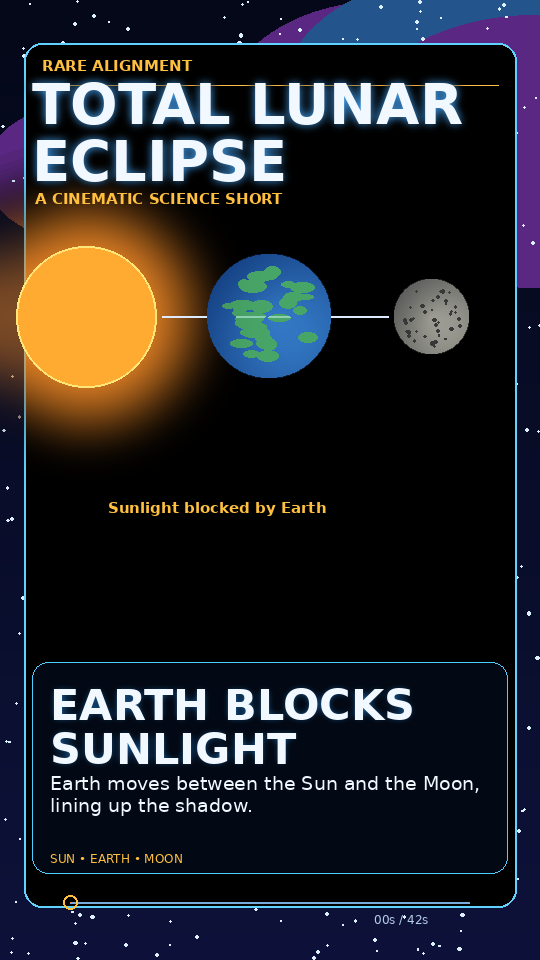

In [5]:
# ==========================
# Frame assembly
# ==========================
def make_frame(frame_idx: int):
    t = frame_idx / FPS
    scene = scene_at(t)
    local = scene_local_t(scene, t)

    img = base_background(t)
    draw_card(img, scene, t)
    draw_scene_visual(img, scene, t, local)

    d = ImageDraw.Draw(img, "RGBA")
    header_y = int(H*0.075)
    if t < 2.5:
        f, lines, lh = fit_font(d, TITLE, int(W*.88), int(H*.12), max(34, W//9), True, 22, max_lines=2)
        y = header_y
        for line in lines:
            glow_text(img, (int(W*.06), y), line, f, fill=WHITE, glow=(70,170,255), radius=5)
            y += lh
        d.text((int(W*.065), y+4), SUBTITLE.upper(), font=FONT_EYEBROW, fill=GOLD+(230,))
    else:
        d.text((int(W*.06), header_y), TITLE, font=FONT_EYEBROW, fill=GOLD+(210,))

    draw_text_panel(img, scene)
    progress_footer(img, t)

    return finalize_frame(img)

def validate_frame_sizes(sample_count=24):
    indices = np.linspace(0, max(0, NFRAMES-1), sample_count).astype(int)
    shapes = []
    for idx in indices:
        arr = make_frame(int(idx))
        shapes.append(arr.shape)
    unique = sorted(set(shapes))
    print("Unique frame shapes:", unique)
    assert unique == [(H, W, 3)], f"Frame shape mismatch: {unique}"
    print("✅ All sampled frames are exactly the same size.")

validate_frame_sizes()
Image.fromarray(make_frame(0))


Saved storyboard preview: lunar_eclipse_cinematic_output/Lunar_Eclipse_Cinematic_Storyboard.png


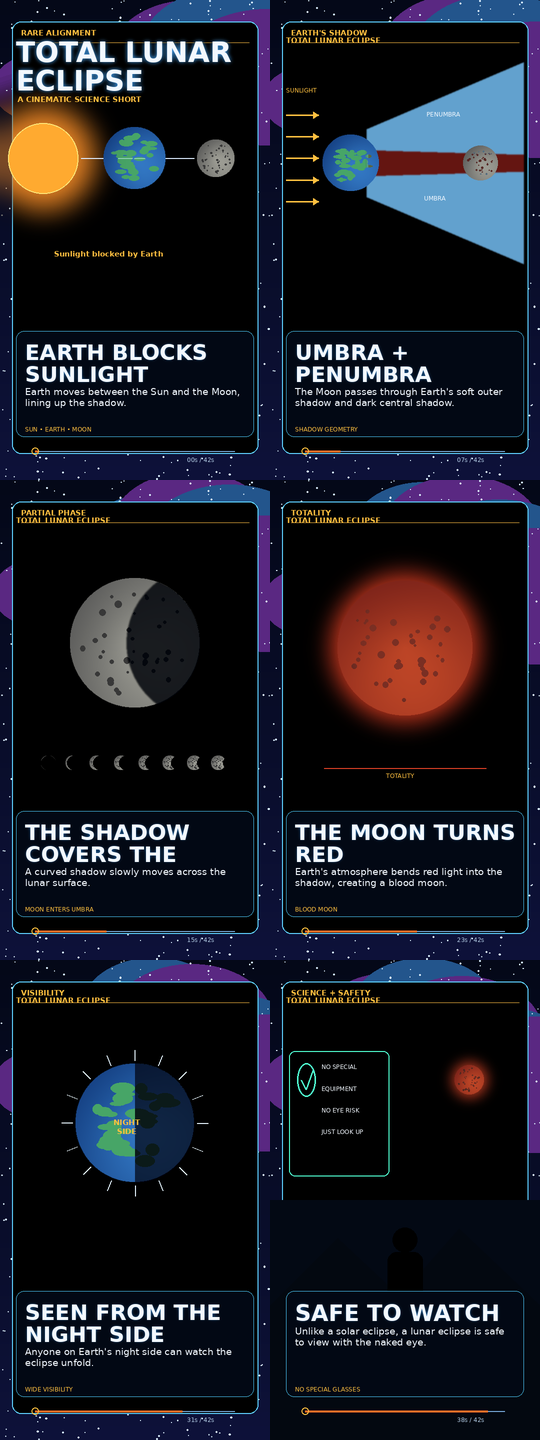

In [8]:
# ==========================
# Render storyboard preview only
# ==========================
preview_times = [0.8, 7.4, 15.0, 23.5, 31.0, 38.5]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]

thumb_w = W // 2
thumb_h = H // 2
contact = Image.new("RGB", (thumb_w * 2, thumb_h * 3), (0, 0, 0))

for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), RESAMPLE)
    contact.paste(thumb, ((idx % 2) * thumb_w, (idx // 2) * thumb_h))

contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact


In [7]:
# ==========================
# Optional: render full vertical MP4
# This cell is safe now because make_frame() always returns exactly (H, W, 3).
# ==========================
validate_frame_sizes()

writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

try:
    for frame_idx in tqdm(range(NFRAMES), desc="Rendering lunar eclipse cinematic short"):
        writer.append_data(make_frame(frame_idx))
finally:
    writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS={FPS} | Size={W}x{H}")


Unique frame shapes: [(960, 540, 3)]
✅ All sampled frames are exactly the same size.


Rendering lunar eclipse cinematic short:   0%|          | 0/840 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video: lunar_eclipse_cinematic_output/Lunar_Eclipse_Cinematic_Info_Shorts.mp4
Duration: 42.0s | FPS=20 | Size=540x960


In [ ]:
# Display video inside the notebook after rendering, if supported
from IPython.display import Video, display

if VIDEO_NAME.exists():
    display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))
else:
    print("Render the MP4 cell first.")


## Notes

The earlier line artifacts usually happen when animated polygons, outlines, masks, or scanline overlays pass across the Moon and then get resized/compressed.

This rebuilt version avoids that by using only smooth filled masks for the lunar shadow and no decorative crossing overlays near the Moon.
